# N06B — Ordinal Refinement of the Locked N06A Performance Model

## Purpose

N06B is a **second exploratory performance experiment** built only after N06A completed.

N06A established that a three-seed ConvNeXt-Base model trained on the expanded OAI KL-labelled cohort reached:

- OAI test QWK **0.8489**;
- NHANES III all-cohort QWK **0.7150**;
- NHANES Confirmation QWK **0.7149**.

N06B asks a narrower follow-up question:

> **Can source-only ordinal refinement of the already-trained N06A models improve the OAI-to-NHANES performance without changing the OAI cohort, split, backbone family, or using NHANES labels for training/selection?**

### Scientific status

N06B is **exploratory / post-hoc**. NHANES results from N06A were already observed before N06B was designed. Therefore the N06B NHANES evaluation is **target-label-free during model development, but it is not a pristine untouched external validation**.

N06B does **not** overwrite N06A. It writes to a separate `N06B` namespace.

### Main design

For each of the same three fixed seeds, N06B:

1. loads the corresponding locked N06A EMA checkpoint;
2. copies only the trained ConvNeXt encoder and five-class KL head;
3. initializes fresh ordinal and continuous-severity heads;
4. fine-tunes with a short learning-rate schedule designed for the observed 20–30 epoch convergence horizon;
5. combines CE expectation, cumulative-ordinal severity, and continuous severity using a **small predeclared blend grid selected on OAI validation only**;
6. freezes the blend and cut-points before NHANES is loaded;
7. evaluates N06B on the same N01 NHANES cohort;
8. performs a paired participant bootstrap against N06A.

The primary endpoint remains **quadratic weighted kappa (QWK)**.

## Locked N06B protocol

Before any N06B NHANES data are loaded, this notebook fixes:

- parent experiment: locked N06A / stage `N06`;
- exact N06A external-lock SHA-256;
- exact N06A OAI source-manifest and patient-split hashes;
- backbone: the same ConvNeXt-Base family as N06A;
- source cohort and split: **exactly the N06A OAI cohort and patient split**;
- parent seeds: `367761876`, `1767922150`, `1023912954`;
- training: source-only ordinal refinement from each corresponding N06A EMA checkpoint;
- maximum refinement: 24 epochs, early stopping on OAI validation only;
- optimizer: differential learning rates for encoder, KL head, and new ordinal heads;
- final inference: three-seed equal-weight ensemble + horizontal-flip TTA;
- inference candidates: a fixed five-member blend grid;
- blend selection and ordinal cut-points: OAI validation only;
- OAI test: evaluated only after all model/blend selection is complete;
- NHANES: loaded only after the N06B external-evaluation lock is written;
- external comparison: paired participant bootstrap versus the already-locked N06A predictions.

No N06A file is modified.

In [ ]:
# 0. Environment and reproducibility

from __future__ import annotations

import copy
import hashlib
import json
import math
import os
import random
import re
import shutil
import subprocess
import sys
import time
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from IPython.display import display

try:
    import timm
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'timm>=1.0.11'])
    import timm

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
)
from scipy.optimize import differential_evolution

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, *args, **kwargs):
        return x

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

if not torch.cuda.is_available():
    raise RuntimeError('N06B requires a CUDA GPU runtime.')

DEVICE = torch.device('cuda')
GPU_NAME = torch.cuda.get_device_name(0)
AMP_DTYPE = torch.bfloat16 if torch.cuda.get_device_capability(0)[0] >= 8 else torch.float16
SCALER_ENABLED = AMP_DTYPE == torch.float16

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

print('GPU:', GPU_NAME)
print('AMP dtype:', AMP_DTYPE)
print('PyTorch:', torch.__version__)
print('timm:', timm.__version__)

Mounted at /content/drive
GPU: NVIDIA A100-SXM4-40GB
AMP dtype: torch.bfloat16
PyTorch: 2.11.0+cu128
timm: 1.0.28


In [ ]:
# 1. Paths, parent N06A contract, and locked N06B configuration

MY_DRIVE = Path('/content/drive/MyDrive')
PROJECT_ROOT = MY_DRIVE / 'Master Thesis'
FINAL_ROOT = MY_DRIVE / 'MasterThesis' / 'Final Pipeline'

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f'Original project root not found: {PROJECT_ROOT}')
if not FINAL_ROOT.exists():
    raise FileNotFoundError(f'Final Pipeline root not found: {FINAL_ROOT}')

OAI_LABELS_PATH = PROJECT_ROOT / 'oai' / 'oai_processed_labels.csv'
OAI_IMAGE_DIR = PROJECT_ROOT / 'oai' / 'processed'
N01_NHANES_PATH = FINAL_ROOT / 'data' / 'N01' / 'nhanes_cohort.csv'
NHANES_IMAGE_DIR = PROJECT_ROOT / 'nhanes3' / 'processed'

PARENT_STAGE = 'N06'
PARENT_LOCK_PATH = FINAL_ROOT / 'config' / PARENT_STAGE / 'n06_external_evaluation_lock.json'
PARENT_MANIFEST_DIR = FINAL_ROOT / 'manifests' / PARENT_STAGE
PARENT_RESULT_DIR = FINAL_ROOT / 'results' / PARENT_STAGE
PARENT_PREDICTION_DIR = FINAL_ROOT / 'predictions' / PARENT_STAGE
PARENT_TABLE_DIR = FINAL_ROOT / 'tables' / PARENT_STAGE

EXPECTED_PARENT_LOCK_SHA = 'ae6d8c5362d06683377cd190c35a1ae875094ca4ffa5f94846b893504d395b88'
EXPECTED_PARENT_CONFIG_SHA = '7d599ff8a4a6853ac0205d1c0c701d2ddcaa3259c90f99b9629bc5bbe795cea9'
EXPECTED_SOURCE_SHA = '1d01eabc7d5a7252f3ebf3572aca6368062821fb89627ef06e0f10dba99edb2d'
EXPECTED_SPLIT_SHA = '007065c379651d851f711e8f6ac87b3d34e4e1cf856c5c4768fcf34e0c7fe0a0'
EXPECTED_PARENT_VARIANT = 'baseline_ce'
EXPECTED_PARENT_BACKBONE = 'convnext_base.fb_in22k_ft_in1k'

STAGE = 'N06B'
PROTOCOL = 'N06B_ORDINAL_REFINEMENT_V1_20260830'
IMPLEMENTATION_REVISION = '2026-08-30_n06b_parent_locked_ordinal_refinement_v1'

RESULT_DIR = FINAL_ROOT / 'results' / STAGE
TABLE_DIR = FINAL_ROOT / 'tables' / STAGE
FIGURE_DIR = FINAL_ROOT / 'figures' / STAGE
CHECKPOINT_DIR = FINAL_ROOT / 'checkpoints' / STAGE
PREDICTION_DIR = FINAL_ROOT / 'predictions' / STAGE
MANIFEST_DIR = FINAL_ROOT / 'manifests' / STAGE
CONFIG_DIR = FINAL_ROOT / 'config' / STAGE
LOCAL_CACHE_ROOT = Path('/content/n06b_images')

for folder in (
    RESULT_DIR, TABLE_DIR, FIGURE_DIR, CHECKPOINT_DIR,
    PREDICTION_DIR, MANIFEST_DIR, CONFIG_DIR, LOCAL_CACHE_ROOT,
):
    folder.mkdir(parents=True, exist_ok=True)


def stable_json(value: Any) -> str:
    return json.dumps(value, sort_keys=True, separators=(',', ':'), default=str)


def sha256_bytes(data: bytes) -> str:
    return hashlib.sha256(data).hexdigest()


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()


def atomic_json(value: Any, path: Path) -> None:
    tmp = path.with_suffix(path.suffix + '.tmp')
    tmp.write_text(json.dumps(value, indent=2, sort_keys=True, default=str), encoding='utf-8')
    tmp.replace(path)


def atomic_csv(frame: pd.DataFrame, path: Path) -> None:
    tmp = path.with_suffix(path.suffix + '.tmp')
    frame.to_csv(tmp, index=False)
    tmp.replace(path)


if not PARENT_LOCK_PATH.exists():
    raise FileNotFoundError(
        f'Locked N06A parent file is missing: {PARENT_LOCK_PATH}. '
        'Run/restore the accepted N06A experiment before N06B.'
    )

PARENT_LOCK = json.loads(PARENT_LOCK_PATH.read_text(encoding='utf-8'))
parent_claimed_hash = PARENT_LOCK.get('lock_sha256')
parent_payload_without_hash = {k: v for k, v in PARENT_LOCK.items() if k != 'lock_sha256'}
parent_recomputed_hash = sha256_bytes(stable_json(parent_payload_without_hash).encode('utf-8'))

if parent_claimed_hash != EXPECTED_PARENT_LOCK_SHA:
    raise RuntimeError(f'N06A claimed lock hash changed: {parent_claimed_hash}')
if parent_recomputed_hash != EXPECTED_PARENT_LOCK_SHA:
    raise RuntimeError(f'N06A recomputed lock hash changed: {parent_recomputed_hash}')
if PARENT_LOCK.get('config_hash') != EXPECTED_PARENT_CONFIG_SHA:
    raise RuntimeError('N06A config hash does not match the audited parent.')
if PARENT_LOCK.get('source_manifest_hash') != EXPECTED_SOURCE_SHA:
    raise RuntimeError('N06A source-manifest hash does not match the audited parent.')
if PARENT_LOCK.get('split_hash') != EXPECTED_SPLIT_SHA:
    raise RuntimeError('N06A split hash does not match the audited parent.')
if PARENT_LOCK.get('selected_variant') != EXPECTED_PARENT_VARIANT:
    raise RuntimeError('N06A selected variant is not the audited baseline_ce parent.')
if PARENT_LOCK.get('backbone') != EXPECTED_PARENT_BACKBONE:
    raise RuntimeError('N06A backbone does not match the audited parent.')
if PARENT_LOCK.get('nhanes_used_for_selection') is not False:
    raise RuntimeError('N06A parent lock does not certify source-only selection.')

PARENT_CHECKPOINTS = PARENT_LOCK.get('final_checkpoints', [])
if len(PARENT_CHECKPOINTS) != 3:
    raise RuntimeError(f'Expected exactly 3 N06A parent checkpoints; found {len(PARENT_CHECKPOINTS)}.')

VERIFIED_PARENT_CHECKPOINTS = {}
for info in PARENT_CHECKPOINTS:
    path = Path(info['path'])
    if not path.exists():
        raise FileNotFoundError(f'N06A parent checkpoint missing: {path}')
    actual = sha256_file(path)
    if actual != info['sha256']:
        raise RuntimeError(f'N06A parent checkpoint SHA mismatch: {path.name}')
    VERIFIED_PARENT_CHECKPOINTS[str(path)] = actual


@dataclass(frozen=True)
class Config:
    protocol: str = PROTOCOL
    training_seeds: tuple[int, int, int] = (367761876, 1767922150, 1023912954)

    image_size: int = 448
    resize_size: int = 512
    batch_size_a100: int = 24
    batch_size_other: int = 8
    num_workers: int = 4
    cache_workers: int = 12

    max_epochs: int = 24
    min_epochs: int = 10
    patience: int = 6
    warmup_epochs: int = 2

    encoder_lr: float = 2.0e-5
    kl_head_lr: float = 5.0e-5
    ordinal_head_lr: float = 1.0e-4
    weight_decay: float = 2.0e-2
    grad_clip: float = 1.0
    min_lr_factor: float = 0.05

    drop_path_rate: float = 0.20
    dropout: float = 0.20
    label_smoothing: float = 0.03
    mixup_probability: float = 0.25
    mixup_alpha: float = 0.20
    random_erasing_probability: float = 0.20
    ema_decay: float = 0.998

    ce_weight: float = 0.52
    ordinal_weight: float = 0.28
    regression_weight: float = 0.05
    ranking_weight: float = 0.13
    monotonic_weight: float = 0.02

    bootstrap_repetitions: int = 2000
    bootstrap_seed: int = 20260830
    li_reference_qwk: float = 0.8640


CONFIG = Config()
BATCH_SIZE = CONFIG.batch_size_a100 if 'A100' in GPU_NAME.upper() else CONFIG.batch_size_other

BLEND_CANDIDATES = {
    'ce_only':            {'ce': 1.00, 'ordinal': 0.00, 'regression': 0.00},
    'ce75_ord25':         {'ce': 0.75, 'ordinal': 0.25, 'regression': 0.00},
    'ce60_ord40':         {'ce': 0.60, 'ordinal': 0.40, 'regression': 0.00},
    'ce70_ord20_reg10':   {'ce': 0.70, 'ordinal': 0.20, 'regression': 0.10},
    'ce60_ord30_reg10':   {'ce': 0.60, 'ordinal': 0.30, 'regression': 0.10},
}

for name, weights in BLEND_CANDIDATES.items():
    if abs(sum(weights.values()) - 1.0) > 1e-12:
        raise RuntimeError(f'Blend weights do not sum to 1 for {name}: {weights}')

loss_weight_sum = (
    CONFIG.ce_weight + CONFIG.ordinal_weight + CONFIG.regression_weight +
    CONFIG.ranking_weight + CONFIG.monotonic_weight
)
if abs(loss_weight_sum - 1.0) > 1e-12:
    raise RuntimeError(f'N06B training loss weights must sum to 1, got {loss_weight_sum}.')

BACKBONE_NAME = EXPECTED_PARENT_BACKBONE

CONFIG_PAYLOAD = {
    'config': asdict(CONFIG),
    'blend_candidates': BLEND_CANDIDATES,
    'backbone': BACKBONE_NAME,
    'protocol': PROTOCOL,
    'implementation_revision': IMPLEMENTATION_REVISION,
    'parent_lock_sha256': EXPECTED_PARENT_LOCK_SHA,
    'parent_config_sha256': EXPECTED_PARENT_CONFIG_SHA,
    'parent_source_sha256': EXPECTED_SOURCE_SHA,
    'parent_split_sha256': EXPECTED_SPLIT_SHA,
}
CONFIG_HASH = sha256_bytes(stable_json(CONFIG_PAYLOAD).encode('utf-8'))
atomic_json(CONFIG_PAYLOAD | {'config_sha256': CONFIG_HASH}, CONFIG_DIR / 'n06b_config.json')

print('N06A parent lock verified:', EXPECTED_PARENT_LOCK_SHA)
print('N06B protocol:', PROTOCOL)
print('Backbone:', BACKBONE_NAME)
print('Batch size:', BATCH_SIZE)
print('N06B config SHA-256:', CONFIG_HASH)

N06A parent lock verified: ae6d8c5362d06683377cd190c35a1ae875094ca4ffa5f94846b893504d395b88
N06B protocol: N06B_ORDINAL_REFINEMENT_V1_20260830
Backbone: convnext_base.fb_in22k_ft_in1k
Batch size: 24
N06B config SHA-256: 792957eeee56a64604ce4b1ff59b68305c9ed83b3a1e76b8d3ff091bc9ea55e2


## 2. Rebuild the N06A OAI universe and prove identity

N06B does not create a new cohort. It reconstructs the eligible OAI KL-labelled knees using the exact N06A/N01 identity parser and requires the resulting source-manifest hash to equal the locked N06A hash.

If the source universe differs by even one row/path/label, the notebook stops.

In [ ]:
# 2. Rebuild the exact N06A all-KL OAI manifest

for required in (OAI_LABELS_PATH, OAI_IMAGE_DIR):
    if not required.exists():
        raise FileNotFoundError(f'Missing source: {required}')

labels_raw = pd.read_csv(OAI_LABELS_PATH, low_memory=False)


def normalize_name(name: str) -> str:
    return re.sub(r'[^a-z0-9]+', '_', str(name).lower()).strip('_')


def resolve_unique_column(frame: pd.DataFrame, aliases: Iterable[str], field: str, required: bool = True):
    lookup: dict[str, list[str]] = {}
    for col in frame.columns:
        lookup.setdefault(normalize_name(col), []).append(str(col))
    matches: list[str] = []
    for alias in aliases:
        matches.extend(lookup.get(normalize_name(alias), []))
    matches = sorted(set(matches))
    if len(matches) == 1:
        return matches[0]
    if not required and len(matches) == 0:
        return None
    raise KeyError(f'Could not resolve {field} uniquely. Matches={matches}; columns={list(frame.columns)}')


def parse_oai_filename(filename: Any) -> tuple[str | None, str | None]:
    text = str(filename)
    subject_match = re.search(r'(\d{7})', text)
    side_match = re.search(r'_(R|L)_', text.upper())
    subject = subject_match.group(1) if subject_match else None
    side = side_match.group(1) if side_match else None
    return subject, side


if parse_oai_filename('prefix_1234567_R_example.png') != ('1234567', 'R'):
    raise RuntimeError('OAI filename parser self-test failed.')

filename_col = resolve_unique_column(
    labels_raw,
    ('filename', 'image', 'image_name', 'filepath', 'path'),
    'OAI filename',
)
kl_col = resolve_unique_column(labels_raw, ('kl_grade', 'kl', 'label', 'grade'), 'OAI KL')

parsed = labels_raw[filename_col].astype(str).apply(parse_oai_filename)
OAI_ALL = pd.DataFrame({
    'source_row': np.arange(len(labels_raw), dtype=int),
    'filename': labels_raw[filename_col].astype(str),
    'patient_id': parsed.map(lambda value: value[0]).astype('string'),
    'knee_side': parsed.map(lambda value: value[1]).astype('string'),
    'kl_grade': pd.to_numeric(labels_raw[kl_col], errors='coerce'),
})
OAI_ALL['patient_id'] = OAI_ALL['patient_id'].astype('string').str.strip()

valid_patient = OAI_ALL['patient_id'].notna() & OAI_ALL['patient_id'].str.fullmatch(r'\d{7}', na=False)
valid_side = OAI_ALL['knee_side'].isin(['L', 'R'])
valid_kl = OAI_ALL['kl_grade'].isin([0, 1, 2, 3, 4])
OAI_ALL['eligible_metadata'] = valid_patient & valid_side & valid_kl


def resolve_exact_image(filename: str, directory: Path) -> Path | None:
    fp = Path(str(filename))
    for candidate in (directory / fp, directory / fp.name):
        if candidate.exists() and candidate.is_file() and candidate.stat().st_size > 0:
            return candidate.resolve()
    return None


resolved = [resolve_exact_image(f, OAI_IMAGE_DIR) for f in tqdm(OAI_ALL['filename'], desc='Resolving OAI images')]
OAI_ALL['source_image_path'] = [str(p) if p is not None else None for p in resolved]
OAI_ALL['image_found'] = OAI_ALL['source_image_path'].notna()
OAI_ALL['eligible'] = OAI_ALL['eligible_metadata'] & OAI_ALL['image_found']

OAI = OAI_ALL.loc[OAI_ALL['eligible']].copy().reset_index(drop=True)
if OAI.empty:
    raise RuntimeError('N06B found zero eligible OAI knees.')
OAI['kl_grade'] = OAI['kl_grade'].astype(int)
OAI['knee_key'] = (
    OAI['patient_id'].astype(str) + '_' +
    OAI['knee_side'].astype(str) + '_' +
    OAI['filename'].map(lambda x: Path(str(x)).stem)
)

if not OAI['knee_key'].is_unique:
    raise RuntimeError('N06B OAI knee_key is not unique.')

SOURCE_MANIFEST_HASH = sha256_bytes(
    OAI[['knee_key', 'patient_id', 'filename', 'kl_grade', 'source_image_path']]
    .sort_values('knee_key')
    .to_csv(index=False)
    .encode('utf-8')
)

if SOURCE_MANIFEST_HASH != EXPECTED_SOURCE_SHA:
    raise RuntimeError(
        'N06B rebuilt OAI source does not match locked N06A. '
        f'Expected {EXPECTED_SOURCE_SHA}, got {SOURCE_MANIFEST_HASH}.'
    )

accounting = pd.DataFrame([
    {'item': 'raw_rows', 'value': len(OAI_ALL)},
    {'item': 'eligible_knees', 'value': len(OAI)},
    {'item': 'eligible_patients', 'value': OAI['patient_id'].nunique()},
    {'item': 'source_manifest_sha256', 'value': SOURCE_MANIFEST_HASH},
])
atomic_csv(accounting, TABLE_DIR / 'T01_oai_identity.csv')
atomic_csv(OAI, MANIFEST_DIR / 'oai_all_kl_manifest.csv')
display(accounting)

print('N06A/N06B OAI source identity: PASS')

Resolving OAI images:   0%|          | 0/8547 [00:00<?, ?it/s]

,item,value
0,raw_rows,8547
1,eligible_knees,8547
2,eligible_patients,4301
3,source_manifest_sha256,1d01eabc7d5a7252f3ebf3572aca6368062821fb89627e...


N06A/N06B OAI source identity: PASS


## 3. Reuse the exact N06A patient split

N06B is not allowed to resplit participants. It loads the three frozen N06A patient-list files and recomputes the split hash using the original algorithm.

In [ ]:
# 3. Load and verify the exact N06A split

TRAIN_PATIENTS_PATH = PARENT_MANIFEST_DIR / 'oai_train_patients.csv'
VAL_PATIENTS_PATH = PARENT_MANIFEST_DIR / 'oai_validation_patients.csv'
TEST_PATIENTS_PATH = PARENT_MANIFEST_DIR / 'oai_test_patients.csv'

for path in (TRAIN_PATIENTS_PATH, VAL_PATIENTS_PATH, TEST_PATIENTS_PATH):
    if not path.exists():
        raise FileNotFoundError(f'N06A split file missing: {path}')

train_ids = set(pd.read_csv(TRAIN_PATIENTS_PATH, dtype='string')['patient_id'].astype(str))
val_ids = set(pd.read_csv(VAL_PATIENTS_PATH, dtype='string')['patient_id'].astype(str))
test_ids = set(pd.read_csv(TEST_PATIENTS_PATH, dtype='string')['patient_id'].astype(str))

if train_ids & val_ids or train_ids & test_ids or val_ids & test_ids:
    raise RuntimeError('N06A/N06B patient split overlap detected.')

all_patients = set(OAI['patient_id'].astype(str))
if train_ids | val_ids | test_ids != all_patients:
    raise RuntimeError('N06A split does not cover the rebuilt N06B OAI universe.')

split_payload = pd.concat([
    pd.DataFrame({'patient_id': sorted(train_ids), 'split': 'train'}),
    pd.DataFrame({'patient_id': sorted(val_ids), 'split': 'validation'}),
    pd.DataFrame({'patient_id': sorted(test_ids), 'split': 'test'}),
]).sort_values(['split', 'patient_id'])

SPLIT_HASH = sha256_bytes(split_payload.to_csv(index=False).encode('utf-8'))
if SPLIT_HASH != EXPECTED_SPLIT_SHA:
    raise RuntimeError(f'N06B split hash mismatch: expected {EXPECTED_SPLIT_SHA}, got {SPLIT_HASH}')

OAI['model_split'] = np.select(
    [
        OAI['patient_id'].astype(str).isin(train_ids),
        OAI['patient_id'].astype(str).isin(val_ids),
        OAI['patient_id'].astype(str).isin(test_ids),
    ],
    ['train', 'validation', 'test'],
    default='unassigned',
)
if OAI['model_split'].eq('unassigned').any():
    raise RuntimeError('Unassigned OAI rows remain.')

split_summary = (
    OAI.groupby('model_split')
    .agg(knees=('knee_key', 'size'), patients=('patient_id', 'nunique'))
    .reset_index()
)
class_summary = OAI.groupby(['model_split', 'kl_grade']).size().reset_index(name='knees')

atomic_csv(split_summary, TABLE_DIR / 'T02_oai_split_summary.csv')
atomic_csv(class_summary, TABLE_DIR / 'T03_oai_split_class_distribution.csv')
display(split_summary)
print('N06A/N06B patient split identity: PASS')
print('Split SHA-256:', SPLIT_HASH)

,model_split,knees,patients
0,test,1284,646
1,train,5981,3010
2,validation,1282,645


N06A/N06B patient split identity: PASS
Split SHA-256: 007065c379651d851f711e8f6ac87b3d34e4e1cf856c5c4768fcf34e0c7fe0a0


## 4. Local cache

N06B first checks whether the current Colab runtime still contains N06A's `/content/n06_images/OAI` cache. If so, it reuses those exact local files. Otherwise it copies from Drive into `/content/n06b_images/OAI`.

This changes I/O time only; it does not change the authoritative source paths or hashes.

In [ ]:
# 4. Cache OAI images with optional same-runtime reuse

OAI_CACHE = LOCAL_CACHE_ROOT / 'OAI'
PARENT_RUNTIME_OAI_CACHE = Path('/content/n06_images/OAI')
OAI_CACHE.mkdir(parents=True, exist_ok=True)


def safe_cache_name(knee_key: str, source: Path) -> str:
    safe = re.sub(r'[^A-Za-z0-9_.-]+', '_', str(knee_key))
    return f'{safe}{source.suffix.lower()}'


def cache_one(
    knee_key: str,
    source_path: str,
    destination_root: Path,
    parent_runtime_root: Path | None = None,
) -> dict[str, Any]:
    source = Path(source_path)
    name = safe_cache_name(knee_key, source)

    if parent_runtime_root is not None:
        parent_candidate = parent_runtime_root / name
        if (
            parent_candidate.exists()
            and parent_candidate.is_file()
            and parent_candidate.stat().st_size == source.stat().st_size
        ):
            return {
                'knee_key': knee_key,
                'image_path': str(parent_candidate),
                'status': 'reused_parent_runtime_cache',
            }

    dest = destination_root / name
    if dest.exists() and dest.stat().st_size == source.stat().st_size:
        return {'knee_key': knee_key, 'image_path': str(dest), 'status': 'cached'}

    tmp = dest.with_suffix(dest.suffix + '.tmp')
    tmp.unlink(missing_ok=True)
    shutil.copyfile(source, tmp)
    if not tmp.exists() or tmp.stat().st_size != source.stat().st_size:
        tmp.unlink(missing_ok=True)
        raise RuntimeError(f'Cache verification failed: {source}')
    tmp.replace(dest)
    return {'knee_key': knee_key, 'image_path': str(dest), 'status': 'copied'}


cache_rows = []
with ThreadPoolExecutor(max_workers=CONFIG.cache_workers) as pool:
    futures = {
        pool.submit(
            cache_one,
            str(r.knee_key),
            str(r.source_image_path),
            OAI_CACHE,
            PARENT_RUNTIME_OAI_CACHE,
        ): r
        for r in OAI.itertuples(index=False)
    }
    for future in tqdm(as_completed(futures), total=len(futures), desc='Caching OAI images'):
        cache_rows.append(future.result())

cache_table = pd.DataFrame(cache_rows)
if len(cache_table) != len(OAI) or not cache_table['knee_key'].is_unique:
    raise RuntimeError('OAI cache cardinality/uniqueness failure.')

OAI = OAI.merge(
    cache_table[['knee_key', 'image_path', 'status']],
    on='knee_key',
    how='left',
    validate='one_to_one',
)
if OAI['image_path'].isna().any():
    raise RuntimeError('At least one OAI row did not receive a local image path.')

atomic_csv(cache_table, TABLE_DIR / 'T04_oai_cache_audit.csv')
print(cache_table['status'].value_counts())

Caching OAI images:   0%|          | 0/8547 [00:00<?, ?it/s]

status
copied    8547
Name: count, dtype: int64


## 5. Data and model

The N06B architecture retains the N06A ConvNeXt encoder and five-class KL head and adds only two trainable auxiliary outputs:

- four cumulative ordinal logits representing \(P(KL > k)\), \(k=0,\dots,3\);
- one bounded continuous severity score in \([0,4]\).

No concept head is used in N06B, preventing the untrained-concept-output issue identified in the N06A audit.

In [ ]:
# 5. Data transforms, datasets, loaders, and source-derived class weights

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((CONFIG.resize_size, CONFIG.resize_size)),
    transforms.RandomCrop(CONFIG.image_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=5, translate=(0.03, 0.03), scale=(0.97, 1.03)),
    transforms.ColorJitter(brightness=0.08, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(
        p=CONFIG.random_erasing_probability,
        scale=(0.02, 0.12),
        ratio=(0.5, 2.0),
        value='random',
    ),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((CONFIG.resize_size, CONFIG.resize_size)),
    transforms.CenterCrop(CONFIG.image_size),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class KneeDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, training: bool):
        self.frame = frame.reset_index(drop=True).copy()
        self.transform = train_transform if training else eval_transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(Path(row['image_path'])) as image:
            image = ImageOps.exif_transpose(image).convert('L')
            image = self.transform(image)
        return {
            'image': image,
            'kl_grade': torch.tensor(int(row['kl_grade']), dtype=torch.long),
            'row_index': torch.tensor(index, dtype=torch.long),
        }


def make_loader(frame: pd.DataFrame, training: bool, seed: int, batch_size: int | None = None):
    generator = torch.Generator()
    generator.manual_seed(seed)
    kwargs = dict(
        dataset=KneeDataset(frame, training=training),
        batch_size=batch_size or BATCH_SIZE,
        shuffle=training,
        num_workers=CONFIG.num_workers,
        pin_memory=True,
        persistent_workers=CONFIG.num_workers > 0,
        generator=generator,
        drop_last=training,
    )
    if CONFIG.num_workers > 0:
        kwargs['prefetch_factor'] = 2
    return DataLoader(**kwargs)


OAI_TRAIN = OAI.loc[OAI['model_split'].eq('train')].reset_index(drop=True)
OAI_VAL = OAI.loc[OAI['model_split'].eq('validation')].reset_index(drop=True)
OAI_TEST = OAI.loc[OAI['model_split'].eq('test')].reset_index(drop=True)

counts = OAI_TRAIN['kl_grade'].value_counts().reindex(range(5), fill_value=1).to_numpy(dtype=float)
class_weights = np.sqrt(counts.sum() / (5.0 * counts))
class_weights = np.clip(class_weights / class_weights.mean(), 0.5, 2.5)
KL_CLASS_WEIGHTS = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

# Moderate source-only threshold balancing for cumulative ordinal BCE.
threshold_pos = np.array([(OAI_TRAIN['kl_grade'].to_numpy() > k).sum() for k in range(4)], dtype=float)
threshold_neg = len(OAI_TRAIN) - threshold_pos
ordinal_pos_weights = np.sqrt(threshold_neg / np.maximum(threshold_pos, 1.0))
ordinal_pos_weights = np.clip(ordinal_pos_weights, 0.7, 2.5)
ORDINAL_POS_WEIGHTS = torch.tensor(ordinal_pos_weights, dtype=torch.float32, device=DEVICE)

print('OAI split sizes:', len(OAI_TRAIN), len(OAI_VAL), len(OAI_TEST))
print('KL class weights:', np.round(class_weights, 3))
print('Ordinal threshold positive weights:', np.round(ordinal_pos_weights, 3))

OAI split sizes: 5981 1282 1284
KL class weights: [0.566 0.834 0.688 0.954 1.959]
Ordinal threshold positive weights: [0.797 1.146 2.217 2.5  ]


In [ ]:
# 6. N06B ordinal-refinement model and exact N06A parent initialization

class OrdinalRefineNet(nn.Module):
    def __init__(self, backbone_name: str):
        super().__init__()
        self.encoder = timm.create_model(
            backbone_name,
            pretrained=False,
            num_classes=0,
            global_pool='avg',
            in_chans=3,
            drop_path_rate=CONFIG.drop_path_rate,
        )
        dim = self.encoder.num_features
        self.dropout = nn.Dropout(CONFIG.dropout)
        self.kl_head = nn.Linear(dim, 5)
        self.ordinal_head = nn.Linear(dim, 4)
        self.severity_head = nn.Linear(dim, 1)

    def forward(self, x):
        features = self.dropout(self.encoder(x))
        return {
            'kl_logits': self.kl_head(features),
            'ordinal_logits': self.ordinal_head(features),
            'severity': 4.0 * torch.sigmoid(self.severity_head(features).squeeze(1)),
        }


def parent_checkpoint_info(seed: int) -> dict[str, Any]:
    matches = [
        info for info in PARENT_CHECKPOINTS
        if f'seed{seed}.pt' in Path(info['path']).name
    ]
    if len(matches) != 1:
        raise RuntimeError(f'Expected one parent checkpoint for seed {seed}, found {len(matches)}.')
    return matches[0]


def initialize_from_parent(seed: int) -> tuple[OrdinalRefineNet, dict[str, Any]]:
    info = parent_checkpoint_info(seed)
    path = Path(info['path'])

    if VERIFIED_PARENT_CHECKPOINTS.get(str(path)) != info['sha256']:
        raise RuntimeError(f'Parent checkpoint was not verified during N06B preflight: {path.name}')

    record = torch.load(path, map_location='cpu', weights_only=False)
    required = {
        'protocol': PARENT_LOCK['protocol'],
        'config_hash': EXPECTED_PARENT_CONFIG_SHA,
        'source_manifest_hash': EXPECTED_SOURCE_SHA,
        'split_hash': EXPECTED_SPLIT_SHA,
        'variant': EXPECTED_PARENT_VARIANT,
        'seed': seed,
        'completed': True,
    }
    mismatches = {k: (record.get(k), v) for k, v in required.items() if record.get(k) != v}
    if mismatches:
        raise RuntimeError(f'Parent checkpoint contract mismatch for seed {seed}: {mismatches}')

    parent_state = record['ema_state']
    model = OrdinalRefineNet(BACKBONE_NAME)

    own_state = model.state_dict()
    transferred = []
    for key in list(own_state):
        if key.startswith('encoder.') or key.startswith('kl_head.'):
            if key not in parent_state:
                raise KeyError(f'Parent state missing required key: {key}')
            if tuple(parent_state[key].shape) != tuple(own_state[key].shape):
                raise RuntimeError(f'Parent shape mismatch for {key}: {parent_state[key].shape} vs {own_state[key].shape}')
            own_state[key] = parent_state[key].detach().cpu().clone()
            transferred.append(key)

    model.load_state_dict(own_state, strict=True)

    # Fresh ordinal/severity heads are intentional and deterministic after set_all_seeds(seed).
    nn.init.trunc_normal_(model.ordinal_head.weight, std=0.02)
    nn.init.zeros_(model.ordinal_head.bias)
    nn.init.trunc_normal_(model.severity_head.weight, std=0.02)
    nn.init.zeros_(model.severity_head.bias)

    transfer_summary = {
        'seed': seed,
        'parent_path': str(path),
        'parent_sha256': info['sha256'],
        'transferred_tensor_count': len(transferred),
        'fresh_heads': ['ordinal_head', 'severity_head'],
    }
    return model, transfer_summary


# Contract-only smoke test using seed 1; no NHANES access.
random.seed(CONFIG.training_seeds[0])
np.random.seed(CONFIG.training_seeds[0])
torch.manual_seed(CONFIG.training_seeds[0])
probe, probe_transfer = initialize_from_parent(CONFIG.training_seeds[0])
probe = probe.to(DEVICE)
with torch.no_grad(), torch.autocast('cuda', dtype=AMP_DTYPE):
    dummy = torch.zeros(2, 3, CONFIG.image_size, CONFIG.image_size, device=DEVICE)
    probe_out = probe(dummy)
if probe_out['kl_logits'].shape != (2, 5):
    raise RuntimeError('KL head smoke test failed.')
if probe_out['ordinal_logits'].shape != (2, 4):
    raise RuntimeError('Ordinal head smoke test failed.')
if probe_out['severity'].shape != (2,):
    raise RuntimeError('Severity head smoke test failed.')
print('Parent transfer smoke test:', probe_transfer)
del probe, dummy, probe_out
torch.cuda.empty_cache()

Parent transfer smoke test: {'seed': 367761876, 'parent_path': '/content/drive/MyDrive/MasterThesis/Final Pipeline/checkpoints/N06/final_baseline_ce_7d599ff8a4a6_seed367761876.pt', 'parent_sha256': '8e52f6ecef4a3061df3c1d5379eb4fd4032e8c6034f87052225d09d7e598ceb8', 'transferred_tensor_count': 344, 'fresh_heads': ['ordinal_head', 'severity_head']}


## 6. Ordinal-refinement objective

N06B uses a fixed source-only multi-objective loss:

\[
L =
0.52L_{CE}
+0.28L_{ordinal}
+0.05L_{regression}
+0.13L_{ranking}
+0.02L_{monotonic}.
\]

The cumulative head is encouraged to satisfy

\[
P(KL>0)\ge P(KL>1)\ge P(KL>2)\ge P(KL>3).
\]

The loss weights are fixed before training and are not adapted using NHANES.

In [ ]:
# 7. Loss functions, MixUp, metrics, and prediction helpers

def one_hot(labels: torch.Tensor, classes: int) -> torch.Tensor:
    return F.one_hot(labels.clamp_min(0), num_classes=classes).float()


def smoothed_one_hot(labels: torch.Tensor, classes: int, smoothing: float) -> torch.Tensor:
    base = one_hot(labels, classes)
    return base * (1.0 - smoothing) + smoothing / classes


def ordinal_targets(labels: torch.Tensor) -> torch.Tensor:
    thresholds = torch.arange(4, device=labels.device).view(1, -1)
    return (labels.view(-1, 1) > thresholds).float()


def weighted_soft_ce(logits, targets, class_weights=None):
    logp = F.log_softmax(logits, dim=1)
    target = targets
    if class_weights is not None:
        target = target * class_weights.view(1, -1)
        target = target / target.sum(dim=1, keepdim=True).clamp_min(1e-8)
    return -(target * logp).sum(dim=1).mean()


def ordinal_bce(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    raw = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    # Soft MixUp targets receive a continuous interpolation between negative weight 1
    # and the source-derived positive threshold weight.
    weights = 1.0 + targets * (ORDINAL_POS_WEIGHTS.view(1, -1) - 1.0)
    return (raw * weights).mean()


def ranking_loss(scores: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    n = scores.numel()
    if n < 2:
        return scores.sum() * 0.0
    i, j = torch.triu_indices(n, n, offset=1, device=scores.device)
    diff_t = targets[i] - targets[j]
    mask = diff_t.abs() >= 0.5
    if not mask.any():
        return scores.sum() * 0.0
    sign = diff_t[mask].sign()
    diff_s = scores[i[mask]] - scores[j[mask]]
    margin = 0.15 * diff_t[mask].abs().clamp(max=4.0)
    return F.softplus(margin - sign * diff_s).mean()


def monotonicity_loss(ordinal_logits: torch.Tensor) -> torch.Tensor:
    p = torch.sigmoid(ordinal_logits)
    violations = F.relu(p[:, 1:] - p[:, :-1])
    return violations.mean()


def prepare_targets(batch, mixup: bool):
    y = batch['kl_grade'].to(DEVICE, non_blocking=True)
    kl_soft = smoothed_one_hot(y, 5, CONFIG.label_smoothing)
    ord_soft = ordinal_targets(y)
    severity = y.float()

    lam = 1.0
    perm = None
    if mixup and random.random() < CONFIG.mixup_probability:
        lam = float(np.random.beta(CONFIG.mixup_alpha, CONFIG.mixup_alpha))
        perm = torch.randperm(y.size(0), device=DEVICE)
        kl_soft = lam * kl_soft + (1.0 - lam) * kl_soft[perm]
        ord_soft = lam * ord_soft + (1.0 - lam) * ord_soft[perm]
        severity = lam * severity + (1.0 - lam) * severity[perm]

    return y, kl_soft, ord_soft, severity, lam, perm


def compute_loss(outputs, target_pack):
    _, kl_soft, ord_soft, severity, _, _ = target_pack

    ce = weighted_soft_ce(outputs['kl_logits'], kl_soft, KL_CLASS_WEIGHTS)
    ordinal = ordinal_bce(outputs['ordinal_logits'], ord_soft)
    regression = F.smooth_l1_loss(outputs['severity'], severity)
    rank = ranking_loss(outputs['severity'], severity)
    monotonic = monotonicity_loss(outputs['ordinal_logits'])

    total = (
        CONFIG.ce_weight * ce +
        CONFIG.ordinal_weight * ordinal +
        CONFIG.regression_weight * regression +
        CONFIG.ranking_weight * rank +
        CONFIG.monotonic_weight * monotonic
    )
    return total, {
        'loss_total': float(total.detach()),
        'loss_ce': float(ce.detach()),
        'loss_ordinal': float(ordinal.detach()),
        'loss_regression': float(regression.detach()),
        'loss_ranking': float(rank.detach()),
        'loss_monotonic': float(monotonic.detach()),
    }


def qwk(y_true, y_pred):
    return float(cohen_kappa_score(y_true, y_pred, weights='quadratic', labels=[0, 1, 2, 3, 4]))


def severe_error_rate(y_true, y_pred):
    return float((np.abs(np.asarray(y_true) - np.asarray(y_pred)) >= 2).mean())


def metrics_from_labels(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    return {
        'n': int(len(y_true)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'qwk': qwk(y_true, y_pred),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', labels=[0,1,2,3,4], zero_division=0)),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'mse': float(mean_squared_error(y_true, y_pred)),
        'severe_error_rate': severe_error_rate(y_true, y_pred),
    }


def softmax_ece(y_true, probs):
    y_true = np.asarray(y_true, dtype=int)
    probs = np.asarray(probs, dtype=float)
    pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (pred == y_true).astype(float)
    bins = np.linspace(0, 1, 11)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidence >= lo) & (confidence < hi if hi < 1 else confidence <= hi)
        if mask.any():
            ece += mask.mean() * abs(correct[mask].mean() - confidence[mask].mean())
    return float(ece)


def apply_cutpoints(scores: np.ndarray, cutpoints: Iterable[float]) -> np.ndarray:
    cuts = np.asarray(list(cutpoints), dtype=float)
    return np.digitize(np.asarray(scores, dtype=float), cuts, right=False).astype(int)


def fit_qwk_cutpoints(y_true: np.ndarray, scores: np.ndarray):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    bounds = [(0.10, 1.40), (0.70, 2.20), (1.40, 3.00), (2.10, 3.90)]

    def objective(x):
        if not np.all(np.diff(x) > 0.05):
            return 10.0
        return 1.0 - qwk(y_true, apply_cutpoints(scores, x))

    result = differential_evolution(
        objective,
        bounds=bounds,
        seed=20260830,
        maxiter=80,
        popsize=12,
        polish=True,
        workers=1,
        updating='immediate',
    )
    cuts = np.asarray(result.x, dtype=float)
    if not np.all(np.diff(cuts) > 0):
        raise RuntimeError(f'Invalid fitted cutpoints: {cuts}')
    return cuts, 1.0 - float(result.fun)


class ModelEMA:
    def __init__(self, model: nn.Module, decay: float):
        self.decay = decay
        self.module = copy.deepcopy(model).eval()
        for parameter in self.module.parameters():
            parameter.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module):
        ema_state = self.module.state_dict()
        model_state = model.state_dict()
        for key, value in ema_state.items():
            src = model_state[key].detach()
            if value.dtype.is_floating_point:
                value.mul_(self.decay).add_(src, alpha=1.0 - self.decay)
            else:
                value.copy_(src)


def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def cosine_with_warmup(optimizer, total_epochs: int, warmup_epochs: int, min_factor: float):
    def factor(epoch):
        if epoch < warmup_epochs:
            return max(1e-3, (epoch + 1) / max(1, warmup_epochs))
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        cosine = 0.5 * (1.0 + math.cos(math.pi * min(max(progress, 0.0), 1.0)))
        return min_factor + (1.0 - min_factor) * cosine
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=factor)


@torch.no_grad()
def predict_model(model: nn.Module, frame: pd.DataFrame, seed: int, tta: bool = False):
    model.eval()
    loader = make_loader(frame, training=False, seed=seed)
    ce_probs = []
    ordinal_scores = []
    regression_scores = []

    for batch in tqdm(loader, desc='Inference', leave=False):
        x = batch['image'].to(DEVICE, non_blocking=True)
        with torch.autocast('cuda', dtype=AMP_DTYPE):
            out = model(x)

            probs = torch.softmax(out['kl_logits'], dim=1)
            ordinal_p = torch.cummin(torch.sigmoid(out['ordinal_logits']), dim=1).values
            ordinal_score = ordinal_p.sum(dim=1)
            regression_score = out['severity']

            if tta:
                out_flip = model(torch.flip(x, dims=[3]))
                probs_flip = torch.softmax(out_flip['kl_logits'], dim=1)
                ordinal_flip = torch.cummin(torch.sigmoid(out_flip['ordinal_logits']), dim=1).values.sum(dim=1)
                regression_flip = out_flip['severity']

                probs = 0.5 * (probs + probs_flip)
                ordinal_score = 0.5 * (ordinal_score + ordinal_flip)
                regression_score = 0.5 * (regression_score + regression_flip)

        ce_probs.append(probs.float().cpu().numpy())
        ordinal_scores.append(ordinal_score.float().cpu().numpy())
        regression_scores.append(regression_score.float().cpu().numpy())

    probs_np = np.concatenate(ce_probs)
    return {
        'ce_probs': probs_np,
        'ce_expected': (probs_np * np.arange(5)[None, :]).sum(axis=1),
        'ordinal_score': np.concatenate(ordinal_scores),
        'regression_score': np.concatenate(regression_scores),
    }


def blend_score(output: dict[str, np.ndarray], weights: dict[str, float]) -> np.ndarray:
    return (
        weights['ce'] * output['ce_expected'] +
        weights['ordinal'] * output['ordinal_score'] +
        weights['regression'] * output['regression_score']
    )

## 7. Three-seed parent-initialized ordinal refinement

There is **no architecture screen in N06B**. The refinement recipe above is fixed once and run for all three thesis seeds.

The checkpoint chosen within each seed is based only on OAI validation. A fixed monitoring score uses:

\[
0.75\,E_{\mathrm{CE}}[KL] + 0.25\,E_{\mathrm{ordinal}}[KL]
\]

with neutral grade boundaries \(0.5,1.5,2.5,3.5\). This is used only for epoch selection; final source-only blend calibration occurs later.

In [ ]:
# 8. Training loop

def checkpoint_path(seed: int) -> Path:
    return CHECKPOINT_DIR / f'ordinal_refine_{CONFIG_HASH[:12]}_seed{seed}.pt'


def cpu_state_dict(model: nn.Module):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def build_optimizer(model: OrdinalRefineNet):
    return torch.optim.AdamW(
        [
            {'params': model.encoder.parameters(), 'lr': CONFIG.encoder_lr},
            {'params': model.kl_head.parameters(), 'lr': CONFIG.kl_head_lr},
            {'params': list(model.ordinal_head.parameters()) + list(model.severity_head.parameters()), 'lr': CONFIG.ordinal_head_lr},
        ],
        weight_decay=CONFIG.weight_decay,
    )


def train_one(seed: int):
    path = checkpoint_path(seed)
    if path.exists():
        saved = torch.load(path, map_location='cpu', weights_only=False)
        required = {
            'protocol': PROTOCOL,
            'config_hash': CONFIG_HASH,
            'parent_lock_sha256': EXPECTED_PARENT_LOCK_SHA,
            'source_manifest_hash': SOURCE_MANIFEST_HASH,
            'split_hash': SPLIT_HASH,
            'seed': seed,
            'completed': True,
        }
        if all(saved.get(k) == v for k, v in required.items()):
            print(f'Reusing validated N06B checkpoint: {path.name}')
            return saved
        raise RuntimeError(f'Existing N06B checkpoint contract mismatch: {path}')

    set_all_seeds(seed)
    model, transfer_summary = initialize_from_parent(seed)
    model = model.to(DEVICE)

    ema = ModelEMA(model, CONFIG.ema_decay)
    optimizer = build_optimizer(model)
    scheduler = cosine_with_warmup(
        optimizer,
        total_epochs=CONFIG.max_epochs,
        warmup_epochs=CONFIG.warmup_epochs,
        min_factor=CONFIG.min_lr_factor,
    )
    scaler = torch.amp.GradScaler('cuda', enabled=SCALER_ENABLED)

    train_loader = make_loader(OAI_TRAIN, training=True, seed=seed)
    val_truth = OAI_VAL['kl_grade'].to_numpy(dtype=int)

    best = None
    best_monitor_qwk = -np.inf
    stale = 0
    history = []
    run_start = time.time()

    for epoch in range(1, CONFIG.max_epochs + 1):
        epoch_start = time.time()
        model.train()
        batch_losses = []

        for batch in tqdm(train_loader, desc=f'N06B:seed{seed}:epoch{epoch}', leave=False):
            x = batch['image'].to(DEVICE, non_blocking=True)
            target_pack = prepare_targets(batch, mixup=True)
            _, _, _, _, lam, perm = target_pack
            if perm is not None:
                x = lam * x + (1.0 - lam) * x[perm]

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast('cuda', dtype=AMP_DTYPE):
                out = model(x)
                loss, pieces = compute_loss(out, target_pack)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG.grad_clip)
            scaler.step(optimizer)
            scaler.update()
            ema.update(model)
            batch_losses.append(pieces)

        scheduler.step()

        val_out = predict_model(ema.module, OAI_VAL, seed=seed, tta=False)
        ce_argmax = val_out['ce_probs'].argmax(axis=1)
        ce_metrics = metrics_from_labels(val_truth, ce_argmax)

        monitor_score = 0.75 * val_out['ce_expected'] + 0.25 * val_out['ordinal_score']
        monitor_pred = apply_cutpoints(monitor_score, [0.5, 1.5, 2.5, 3.5])
        monitor_metrics = metrics_from_labels(val_truth, monitor_pred)

        ordinal_pred = apply_cutpoints(val_out['ordinal_score'], [0.5, 1.5, 2.5, 3.5])
        ordinal_metrics = metrics_from_labels(val_truth, ordinal_pred)

        mean_losses = pd.DataFrame(batch_losses).mean(numeric_only=True).to_dict()
        epoch_seconds = time.time() - epoch_start

        row = {
            'seed': seed,
            'epoch': epoch,
            'epoch_seconds': epoch_seconds,
            'encoder_lr': optimizer.param_groups[0]['lr'],
            'kl_head_lr': optimizer.param_groups[1]['lr'],
            'ordinal_head_lr': optimizer.param_groups[2]['lr'],
            **mean_losses,
            **{f'val_ce_{k}': v for k, v in ce_metrics.items()},
            **{f'val_monitor_{k}': v for k, v in monitor_metrics.items()},
            **{f'val_ordinal_{k}': v for k, v in ordinal_metrics.items()},
        }
        history.append(row)

        print(
            f'N06B seed={seed} epoch={epoch}: '
            f'monitor QWK={monitor_metrics["qwk"]:.4f}, '
            f'CE argmax QWK={ce_metrics["qwk"]:.4f}, '
            f'ordinal QWK={ordinal_metrics["qwk"]:.4f}, '
            f'{epoch_seconds:.1f}s'
        )

        if epoch == 1:
            projected = epoch_seconds * CONFIG.max_epochs / 3600.0
            print(f'Projected upper-bound training time for this seed at current speed: {projected:.2f} h')

        improved = monitor_metrics['qwk'] > best_monitor_qwk + 1e-5
        if improved:
            best_monitor_qwk = monitor_metrics['qwk']
            stale = 0
            best = {
                'epoch': epoch,
                'monitor_metrics': monitor_metrics,
                'ce_metrics': ce_metrics,
                'ordinal_metrics': ordinal_metrics,
                'ema_state': cpu_state_dict(ema.module),
            }
        else:
            stale += 1

        if epoch >= CONFIG.min_epochs and stale >= CONFIG.patience:
            print(f'N06B early stopping at epoch {epoch}.')
            break

    if best is None:
        raise RuntimeError(f'No best N06B checkpoint was recorded for seed {seed}.')

    record = {
        'protocol': PROTOCOL,
        'config_hash': CONFIG_HASH,
        'parent_lock_sha256': EXPECTED_PARENT_LOCK_SHA,
        'source_manifest_hash': SOURCE_MANIFEST_HASH,
        'split_hash': SPLIT_HASH,
        'backbone': BACKBONE_NAME,
        'seed': seed,
        'completed': True,
        'best_epoch': best['epoch'],
        'best_monitor_metrics': best['monitor_metrics'],
        'best_ce_metrics': best['ce_metrics'],
        'best_ordinal_metrics': best['ordinal_metrics'],
        'ema_state': best['ema_state'],
        'history': history,
        'transfer_summary': transfer_summary,
        'training_seconds': time.time() - run_start,
        'saved_utc': datetime.now(timezone.utc).isoformat(),
    }
    torch.save(record, path)

    del model, ema, optimizer, train_loader
    torch.cuda.empty_cache()
    return record


FINAL_RECORDS = [train_one(seed) for seed in CONFIG.training_seeds]

seed_summary = pd.DataFrame([
    {
        'seed': record['seed'],
        'best_epoch': record['best_epoch'],
        'training_minutes': record['training_seconds'] / 60.0,
        'monitor_qwk': record['best_monitor_metrics']['qwk'],
        'ce_argmax_qwk': record['best_ce_metrics']['qwk'],
        'ordinal_qwk': record['best_ordinal_metrics']['qwk'],
        'checkpoint': str(checkpoint_path(record['seed'])),
    }
    for record in FINAL_RECORDS
])
atomic_csv(seed_summary, TABLE_DIR / 'T05_final_seed_validation.csv')
display(seed_summary.round(4))

Reusing validated N06B checkpoint: ordinal_refine_792957eeee56_seed367761876.pt


N06B:seed1767922150:epoch1:   0%|          | 0/249 [00:00<?, ?it/s]

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

N06B seed=1767922150 epoch=1: monitor QWK=0.8014, CE argmax QWK=0.8165, ordinal QWK=0.4157, 93.6s
Projected upper-bound training time for this seed at current speed: 0.62 h


N06B:seed1767922150:epoch2:   0%|          | 0/249 [00:00<?, ?it/s]

...

N06B seed=1023912954 epoch=9: monitor QWK=0.7965, CE argmax QWK=0.7894, ordinal QWK=0.8055, 71.0s


N06B:seed1023912954:epoch10:   0%|          | 0/249 [00:00<?, ?it/s]

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

N06B seed=1023912954 epoch=10: monitor QWK=0.7941, CE argmax QWK=0.7895, ordinal QWK=0.8042, 70.7s
N06B early stopping at epoch 10.


,seed,best_epoch,training_minutes,monitor_qwk,ce_argmax_qwk,ordinal_qwk,checkpoint
0,367761876,4,12.1672,0.8244,0.8128,0.8189,/content/drive/MyDrive/MasterThesis/Final Pipe...
1,1767922150,3,12.1786,0.8284,0.8169,0.8120,/content/drive/MyDrive/MasterThesis/Final Pipe...
2,1023912954,3,11.8085,0.8162,0.8090,0.8003,/content/drive/MyDrive/MasterThesis/Final Pipe...


## 8. Source-only ensemble, blend selection, and OAI test

All three seed checkpoints are retained.

N06B evaluates the five predeclared CE/ordinal/regression blends on **OAI validation only**. Each blend receives its own OAI-validation-fitted cut-points. The highest validation QWK wins, with MAE and severe-error rate as deterministic tie-breakers.

Only then is the OAI test evaluated.

In [ ]:
# 9. Ensemble, source-only blend selection, and OAI test

def load_ema_model(record):
    model = OrdinalRefineNet(BACKBONE_NAME).to(DEVICE)
    model.load_state_dict(record['ema_state'], strict=True)
    model.eval()
    return model


FINAL_MODELS = [load_ema_model(record) for record in FINAL_RECORDS]


def ensemble_predict(models, frame, seed_base=0, tta=True):
    outputs = [
        predict_model(model, frame, seed=seed_base + i, tta=tta)
        for i, model in enumerate(models)
    ]
    return {
        'ce_probs': np.mean([o['ce_probs'] for o in outputs], axis=0),
        'ce_expected': np.mean([o['ce_expected'] for o in outputs], axis=0),
        'ordinal_score': np.mean([o['ordinal_score'] for o in outputs], axis=0),
        'regression_score': np.mean([o['regression_score'] for o in outputs], axis=0),
    }


VAL_ENSEMBLE = ensemble_predict(FINAL_MODELS, OAI_VAL, seed_base=1000, tta=True)
val_truth = OAI_VAL['kl_grade'].to_numpy(dtype=int)

blend_rows = []
blend_cache = {}
for blend_name, weights in BLEND_CANDIDATES.items():
    score = blend_score(VAL_ENSEMBLE, weights)
    cuts, fitted_qwk = fit_qwk_cutpoints(val_truth, score)
    pred = apply_cutpoints(score, cuts)
    metrics = metrics_from_labels(val_truth, pred)
    blend_cache[blend_name] = {
        'weights': weights,
        'score': score,
        'cutpoints': cuts,
        'pred': pred,
        'metrics': metrics,
    }
    blend_rows.append({
        'blend': blend_name,
        **weights,
        **metrics,
        'cutpoint_0': cuts[0],
        'cutpoint_1': cuts[1],
        'cutpoint_2': cuts[2],
        'cutpoint_3': cuts[3],
        'optimizer_qwk': fitted_qwk,
    })

BLEND_TABLE = pd.DataFrame(blend_rows).sort_values(
    ['qwk', 'mae', 'severe_error_rate', 'blend'],
    ascending=[False, True, True, True],
).reset_index(drop=True)

SELECTED_BLEND = str(BLEND_TABLE.iloc[0]['blend'])
SELECTED_WEIGHTS = BLEND_CANDIDATES[SELECTED_BLEND]
FINAL_CUTPOINTS = blend_cache[SELECTED_BLEND]['cutpoints']
VAL_SCORE = blend_cache[SELECTED_BLEND]['score']
VAL_PRED = blend_cache[SELECTED_BLEND]['pred']
VAL_METRICS = blend_cache[SELECTED_BLEND]['metrics']

VAL_ARGMAX_PRED = VAL_ENSEMBLE['ce_probs'].argmax(axis=1)
VAL_ARGMAX_METRICS = metrics_from_labels(val_truth, VAL_ARGMAX_PRED)
VAL_ARGMAX_METRICS['ece'] = softmax_ece(val_truth, VAL_ENSEMBLE['ce_probs'])

atomic_csv(BLEND_TABLE, TABLE_DIR / 'T06_source_blend_selection.csv')
display(BLEND_TABLE.round(4))

print('SELECTED BLEND:', SELECTED_BLEND, SELECTED_WEIGHTS)
print('Frozen OAI-validation cutpoints:', np.round(FINAL_CUTPOINTS, 4))
print('OAI validation primary:', VAL_METRICS)
print('OAI validation softmax-argmax sensitivity:', VAL_ARGMAX_METRICS)

TEST_ENSEMBLE = ensemble_predict(FINAL_MODELS, OAI_TEST, seed_base=2000, tta=True)
test_truth = OAI_TEST['kl_grade'].to_numpy(dtype=int)
TEST_SCORE = blend_score(TEST_ENSEMBLE, SELECTED_WEIGHTS)
TEST_PRED = apply_cutpoints(TEST_SCORE, FINAL_CUTPOINTS)
TEST_METRICS = metrics_from_labels(test_truth, TEST_PRED)

TEST_ARGMAX_PRED = TEST_ENSEMBLE['ce_probs'].argmax(axis=1)
TEST_ARGMAX_METRICS = metrics_from_labels(test_truth, TEST_ARGMAX_PRED)
TEST_ARGMAX_METRICS['ece'] = softmax_ece(test_truth, TEST_ENSEMBLE['ce_probs'])

PARENT_OAI_TEST_QWK = float(PARENT_LOCK['oai_test_metrics']['qwk'])

print('OAI test primary:', TEST_METRICS)
print('OAI test softmax-argmax sensitivity:', TEST_ARGMAX_METRICS)
print(f'N06B minus N06A OAI-test QWK: {TEST_METRICS["qwk"] - PARENT_OAI_TEST_QWK:+.4f}')


def prediction_frame(frame, output, score, pred, subset):
    result = frame[['knee_key', 'patient_id', 'filename', 'kl_grade']].copy()
    result['subset'] = subset
    result['predicted_kl'] = pred
    result['final_score'] = score
    result['ce_expected'] = output['ce_expected']
    result['ordinal_score'] = output['ordinal_score']
    result['regression_score'] = output['regression_score']
    for k in range(5):
        result[f'kl_prob_{k}'] = output['ce_probs'][:, k]
    return result


OAI_VAL_PRED = prediction_frame(OAI_VAL, VAL_ENSEMBLE, VAL_SCORE, VAL_PRED, 'OAI_validation')
OAI_TEST_PRED = prediction_frame(OAI_TEST, TEST_ENSEMBLE, TEST_SCORE, TEST_PRED, 'OAI_test')
atomic_csv(OAI_VAL_PRED, PREDICTION_DIR / 'oai_validation_predictions.csv')
atomic_csv(OAI_TEST_PRED, PREDICTION_DIR / 'oai_test_predictions.csv')

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e9ab0f1b1a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e9ab0f1b1a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

,blend,ce,ordinal,regression,n,accuracy,qwk,macro_f1,mae,mse,severe_error_rate,cutpoint_0,cutpoint_1,cutpoint_2,cutpoint_3,optimizer_qwk
0,ce75_ord25,0.75,0.25,0.0,1282,0.6435,0.8382,0.6746,0.3931,0.4665,0.0367,0.5417,1.8601,2.1428,3.0910,0.8382
1,ce_only,1.00,0.00,0.0,1282,0.6505,0.8379,0.6673,0.3931,0.4805,0.0437,0.7301,1.8498,2.1096,3.0514,0.8379
2,ce60_ord30_reg10,0.60,0.30,0.1,1282,0.6404,0.8368,0.6673,0.3986,0.4766,0.0390,0.6087,1.8771,2.2072,3.1145,0.8368
3,ce60_ord40,0.60,0.40,0.0,1282,0.6451,0.8363,0.6708,0.3947,0.4743,0.0398,0.6204,1.8358,2.2102,3.1304,0.8363
4,ce70_ord20_reg10,0.70,0.20,0.1,1282,0.6443,0.8352,0.6683,0.3970,0.4797,0.0413,0.6367,1.8631,2.2024,3.3343,0.8352


SELECTED BLEND: ce75_ord25 {'ce': 0.75, 'ordinal': 0.25, 'regression': 0.0}
Frozen OAI-validation cutpoints: [0.5417 1.8601 2.1428 3.091 ]
OAI validation primary: {'n': 1282, 'accuracy': 0.6435257410296412, 'qwk': 0.8382259969123844, 'macro_f1': 0.6745809827664508, 'mae': 0.39313572542901715, 'mse': 0.4664586583463339, 'severe_error_rate': 0.036661466458658344}
OAI validation softmax-argmax sensitivity: {'n': 1282, 'accuracy': 0.6606864274570983, 'qwk': 0.822704711701775, 'macro_f1': 0.678817293213082, 'mae': 0.3962558502340094, 'mse': 0.5101404056162246, 'severe_error_rate': 0.05694227769110764, 'ece': 0.15592606598148107}


Inference:   0%|          | 0/54 [00:00<?, ?it/s]

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

OAI test primary: {'n': 1284, 'accuracy': 0.6448598130841121, 'qwk': 0.8455068190227034, 'macro_f1': 0.6807627987638702, 'mae': 0.38161993769470404, 'mse': 0.43613707165109034, 'severe_error_rate': 0.02570093457943925}
OAI test softmax-argmax sensitivity: {'n': 1284, 'accuracy': 0.676791277258567, 'qwk': 0.8353643981013796, 'macro_f1': 0.6986304295835688, 'mae': 0.36838006230529596, 'mse': 0.4618380062305296, 'severe_error_rate': 0.04361370716510903, 'ece': 0.14130031101614515}
N06B minus N06A OAI-test QWK: -0.0034


## 9. N06B external-evaluation lock

This lock is written **before any NHANES file is opened by N06B**.

It records the exact parent lock, all three N06B checkpoints, source/split hashes, selected OAI-only blend, cut-points, and OAI test results.

In [ ]:
# 10. Freeze N06B before NHANES is loaded

final_checkpoint_paths = [checkpoint_path(seed) for seed in CONFIG.training_seeds]
for path in final_checkpoint_paths:
    if not path.exists():
        raise FileNotFoundError(path)

FINAL_LOCK = {
    'stage': STAGE,
    'protocol': PROTOCOL,
    'locked_utc': datetime.now(timezone.utc).isoformat(),
    'exploratory_post_hoc': True,
    'parent_stage': PARENT_STAGE,
    'parent_lock_sha256': EXPECTED_PARENT_LOCK_SHA,
    'config_hash': CONFIG_HASH,
    'source_manifest_hash': SOURCE_MANIFEST_HASH,
    'split_hash': SPLIT_HASH,
    'backbone': BACKBONE_NAME,
    'training_seeds': list(CONFIG.training_seeds),
    'selected_blend': SELECTED_BLEND,
    'selected_blend_weights': SELECTED_WEIGHTS,
    'oai_validation_cutpoints': [float(x) for x in FINAL_CUTPOINTS],
    'oai_validation_metrics': VAL_METRICS,
    'oai_validation_argmax_metrics': VAL_ARGMAX_METRICS,
    'oai_test_metrics': TEST_METRICS,
    'oai_test_argmax_metrics': TEST_ARGMAX_METRICS,
    'final_checkpoints': [
        {'path': str(path), 'sha256': sha256_file(path)}
        for path in final_checkpoint_paths
    ],
    'nhanes_used_for_training': False,
    'nhanes_used_for_epoch_selection': False,
    'nhanes_used_for_blend_selection': False,
    'nhanes_used_for_cutpoint_fitting': False,
    'external_status_note': (
        'NHANES was previously observed in N06A before N06B design; '
        'N06B is target-label-free during development but not a pristine untouched external validation.'
    ),
}

FINAL_LOCK_HASH = sha256_bytes(stable_json(FINAL_LOCK).encode('utf-8'))
FINAL_LOCK['lock_sha256'] = FINAL_LOCK_HASH
LOCK_PATH = CONFIG_DIR / 'n06b_external_evaluation_lock.json'
atomic_json(FINAL_LOCK, LOCK_PATH)

print('N06B EXTERNAL EVALUATION LOCK WRITTEN')
print('Lock:', LOCK_PATH)
print('Lock SHA-256:', FINAL_LOCK_HASH)

N06B EXTERNAL EVALUATION LOCK WRITTEN
Lock: /content/drive/MyDrive/MasterThesis/Final Pipeline/config/N06B/n06b_external_evaluation_lock.json
Lock SHA-256: 688965cbee72d05e7fe1c2a31b8b49a89ba74b1a6ddbf6c69733e0c72fa3801b


# 10. NHANES evaluation — exploratory repeated external benchmark

**Only now does N06B load NHANES.**

No NHANES label changes the N06B weights, epoch choices, blend weights, or cut-points.

Because N06A's NHANES result was already known before N06B was designed, the result below must be described as an **exploratory repeated external benchmark**, not a fresh confirmatory external validation.

In [ ]:
# 11. Load and validate NHANES only after the N06B lock exists

if not LOCK_PATH.exists():
    raise RuntimeError('N06B external lock does not exist. NHANES evaluation is prohibited.')

lock_check = json.loads(LOCK_PATH.read_text(encoding='utf-8'))
for key, expected in {
    'protocol': PROTOCOL,
    'config_hash': CONFIG_HASH,
    'parent_lock_sha256': EXPECTED_PARENT_LOCK_SHA,
    'source_manifest_hash': SOURCE_MANIFEST_HASH,
    'split_hash': SPLIT_HASH,
    'selected_blend': SELECTED_BLEND,
}.items():
    if lock_check.get(key) != expected:
        raise RuntimeError(f'N06B external lock mismatch for {key}.')

if not N01_NHANES_PATH.exists():
    raise FileNotFoundError(f'N01 NHANES cohort not found: {N01_NHANES_PATH}')
if not NHANES_IMAGE_DIR.exists():
    raise FileNotFoundError(f'NHANES processed image directory not found: {NHANES_IMAGE_DIR}')

NHANES = pd.read_csv(N01_NHANES_PATH, low_memory=False)
required = {'knee_key', 'patient_id', 'filename', 'kl_grade'}
missing = required - set(NHANES.columns)
if missing:
    raise KeyError(f'N01 NHANES cohort missing columns: {sorted(missing)}')
if not NHANES['knee_key'].astype(str).is_unique:
    raise RuntimeError('N01 NHANES knee_key is not unique.')

NHANES['patient_id'] = NHANES['patient_id'].astype(str)
NHANES['kl_grade'] = pd.to_numeric(NHANES['kl_grade'], errors='coerce')
if not NHANES['kl_grade'].isin([0,1,2,3,4]).all():
    raise RuntimeError('NHANES contains invalid/missing KL values.')
NHANES['kl_grade'] = NHANES['kl_grade'].astype(int)

resolved = [
    resolve_exact_image(filename, NHANES_IMAGE_DIR)
    for filename in tqdm(NHANES['filename'], desc='Resolving NHANES images')
]
if any(path is None for path in resolved):
    missing_idx = [i for i, path in enumerate(resolved) if path is None]
    display(NHANES.iloc[missing_idx[:20]][['knee_key', 'filename']])
    raise FileNotFoundError(f'{len(missing_idx)} NHANES images could not be resolved.')

NHANES['source_image_path'] = [str(path) for path in resolved]

print('NHANES knees:', len(NHANES))
print('NHANES patients:', NHANES['patient_id'].nunique())
if 'analysis_subset' in NHANES.columns:
    print(NHANES['analysis_subset'].value_counts(dropna=False))

Resolving NHANES images:   0%|          | 0/4781 [00:00<?, ?it/s]

NHANES knees: 4781
NHANES patients: 2410
analysis_subset
Confirmation    2392
Discovery       2389
Name: count, dtype: int64


In [ ]:
# 12. Cache NHANES with optional N06A same-runtime reuse

NHANES_CACHE = LOCAL_CACHE_ROOT / 'NHANES'
PARENT_RUNTIME_NHANES_CACHE = Path('/content/n06_images/NHANES')
NHANES_CACHE.mkdir(parents=True, exist_ok=True)

cache_rows = []
with ThreadPoolExecutor(max_workers=CONFIG.cache_workers) as pool:
    futures = {
        pool.submit(
            cache_one,
            str(r.knee_key),
            str(r.source_image_path),
            NHANES_CACHE,
            PARENT_RUNTIME_NHANES_CACHE,
        ): r
        for r in NHANES.itertuples(index=False)
    }
    for future in tqdm(as_completed(futures), total=len(futures), desc='Caching NHANES images'):
        cache_rows.append(future.result())

nhanes_cache_table = pd.DataFrame(cache_rows)
if len(nhanes_cache_table) != len(NHANES) or not nhanes_cache_table['knee_key'].is_unique:
    raise RuntimeError('NHANES cache cardinality/uniqueness failure.')

NHANES = NHANES.merge(
    nhanes_cache_table[['knee_key', 'image_path', 'status']],
    on='knee_key',
    how='left',
    validate='one_to_one',
)
if NHANES['image_path'].isna().any():
    raise RuntimeError('NHANES local path assignment failed.')

atomic_csv(nhanes_cache_table, TABLE_DIR / 'T07_nhanes_cache_audit.csv')
print(nhanes_cache_table['status'].value_counts())

Caching NHANES images:   0%|          | 0/4781 [00:00<?, ?it/s]

status
copied    4781
Name: count, dtype: int64


In [ ]:
# 13. N06B external evaluation

EXTERNAL = ensemble_predict(FINAL_MODELS, NHANES, seed_base=3000, tta=True)
external_truth = NHANES['kl_grade'].to_numpy(dtype=int)
EXTERNAL_SCORE = blend_score(EXTERNAL, SELECTED_WEIGHTS)
EXTERNAL_PRED = apply_cutpoints(EXTERNAL_SCORE, FINAL_CUTPOINTS)
EXTERNAL_METRICS = metrics_from_labels(external_truth, EXTERNAL_PRED)

EXTERNAL_ARGMAX_PRED = EXTERNAL['ce_probs'].argmax(axis=1)
EXTERNAL_ARGMAX_METRICS = metrics_from_labels(external_truth, EXTERNAL_ARGMAX_PRED)
EXTERNAL_ARGMAX_METRICS['ece'] = softmax_ece(external_truth, EXTERNAL['ce_probs'])

external_rows = [
    {
        'subset': 'NHANES_all_N01',
        'prediction_rule': 'N06B_OAI_validation_blend_and_cutpoints',
        **EXTERNAL_METRICS,
    },
    {
        'subset': 'NHANES_all_N01',
        'prediction_rule': 'softmax_argmax_sensitivity',
        **EXTERNAL_ARGMAX_METRICS,
    },
]

confirmation_metrics = None
if 'analysis_subset' in NHANES.columns:
    normalized_subset = NHANES['analysis_subset'].astype(str).str.lower()
    confirmation_mask = normalized_subset.str.contains('confirm').to_numpy()
    if confirmation_mask.any():
        c_truth = external_truth[confirmation_mask]
        c_pred = EXTERNAL_PRED[confirmation_mask]
        confirmation_metrics = metrics_from_labels(c_truth, c_pred)
        external_rows.append({
            'subset': 'NHANES_confirmation',
            'prediction_rule': 'N06B_OAI_validation_blend_and_cutpoints',
            **confirmation_metrics,
        })

EXTERNAL_TABLE = pd.DataFrame(external_rows)
atomic_csv(EXTERNAL_TABLE, TABLE_DIR / 'T08_external_performance.csv')
display(EXTERNAL_TABLE.round(4))

NHANES_PRED = prediction_frame(
    NHANES,
    EXTERNAL,
    EXTERNAL_SCORE,
    EXTERNAL_PRED,
    'NHANES_all_N01',
)
atomic_csv(NHANES_PRED, PREDICTION_DIR / 'nhanes_all_predictions.csv')

print(f'N06B external QWK (primary): {EXTERNAL_METRICS["qwk"]:.4f}')
print(f'N06B external QWK (softmax argmax sensitivity): {EXTERNAL_ARGMAX_METRICS["qwk"]:.4f}')
print(f'Difference from Li reference 0.8640: {EXTERNAL_METRICS["qwk"] - CONFIG.li_reference_qwk:+.4f}')

Inference:   0%|          | 0/200 [00:00<?, ?it/s]

Inference:   0%|          | 0/200 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e9ab0f1b1a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e9ab0f1b1a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Inference:   0%|          | 0/200 [00:00<?, ?it/s]

,subset,prediction_rule,n,accuracy,qwk,macro_f1,mae,mse,severe_error_rate,ece
0,NHANES_all_N01,N06B_OAI_validation_blend_and_cutpoints,4781,0.4913,0.6852,0.4148,0.5842,0.7657,0.0613,NaN
1,NHANES_all_N01,softmax_argmax_sensitivity,4781,0.5842,0.6117,0.4103,0.5963,1.0280,0.1544,0.1716
2,NHANES_confirmation,N06B_OAI_validation_blend_and_cutpoints,2392,0.4979,0.6873,0.4136,0.5786,0.7584,0.0644,NaN


N06B external QWK (primary): 0.6852
N06B external QWK (softmax argmax sensitivity): 0.6117
Difference from Li reference 0.8640: -0.1788


## 11. Participant bootstrap and paired N06A-vs-N06B comparison

The primary N06B interval resamples **participants**, keeping both knees together.

After the N06B external result exists, the notebook also loads the already-frozen N06A prediction file and performs a **paired participant bootstrap** of

\[
\Delta QWK = QWK_{N06B} - QWK_{N06A}.
\]

This paired comparison is more informative than comparing two independent confidence intervals.

In [ ]:
# 14. Participant bootstrap interval for N06B

def participant_bootstrap(frame: pd.DataFrame, y_pred: np.ndarray, repetitions: int, seed: int):
    work = frame[['patient_id', 'kl_grade']].copy().reset_index(drop=True)
    work['pred'] = np.asarray(y_pred, dtype=int)
    work['row_id'] = np.arange(len(work))

    groups = {
        str(pid): group['row_id'].to_numpy(dtype=int)
        for pid, group in work.groupby(work['patient_id'].astype(str))
    }
    patients = np.array(sorted(groups), dtype=object)
    rng = np.random.default_rng(seed)
    truth_all = work['kl_grade'].to_numpy(dtype=int)
    pred_all = work['pred'].to_numpy(dtype=int)

    rows = []
    for replicate in tqdm(range(repetitions), desc='N06B participant bootstrap'):
        sampled = rng.choice(patients, size=len(patients), replace=True)
        idx = np.concatenate([groups[pid] for pid in sampled])
        truth = truth_all[idx]
        pred = pred_all[idx]
        rows.append({
            'replicate': replicate,
            'qwk': qwk(truth, pred),
            'accuracy': float(accuracy_score(truth, pred)),
            'mae': float(mean_absolute_error(truth, pred)),
        })
    return pd.DataFrame(rows)


BOOT = participant_bootstrap(
    NHANES,
    EXTERNAL_PRED,
    CONFIG.bootstrap_repetitions,
    CONFIG.bootstrap_seed,
)
atomic_csv(BOOT, RESULT_DIR / 'external_participant_bootstrap.csv')

interval_rows = []
for metric in ('qwk', 'accuracy', 'mae'):
    values = BOOT[metric].to_numpy(dtype=float)
    interval_rows.append({
        'metric': metric,
        'estimate': EXTERNAL_METRICS[metric],
        'lower_95': float(np.quantile(values, 0.025)),
        'upper_95': float(np.quantile(values, 0.975)),
    })

INTERVALS = pd.DataFrame(interval_rows)
atomic_csv(INTERVALS, TABLE_DIR / 'T09_external_bootstrap_intervals.csv')
display(INTERVALS.round(4))

N06B participant bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

,metric,estimate,lower_95,upper_95
0,qwk,0.6852,0.6658,0.7046
1,accuracy,0.4913,0.4753,0.5072
2,mae,0.5842,0.5629,0.6059


In [ ]:
# 15. Paired participant bootstrap versus the locked N06A predictions

PARENT_STATUS_PATH = PARENT_RESULT_DIR / 'status.json'
PARENT_EXTERNAL_PRED_PATH = PARENT_PREDICTION_DIR / 'nhanes_all_predictions.csv'

if not PARENT_STATUS_PATH.exists():
    raise FileNotFoundError(f'N06A status file missing: {PARENT_STATUS_PATH}')
if not PARENT_EXTERNAL_PRED_PATH.exists():
    raise FileNotFoundError(f'N06A external predictions missing: {PARENT_EXTERNAL_PRED_PATH}')

PARENT_STATUS = json.loads(PARENT_STATUS_PATH.read_text(encoding='utf-8'))
if PARENT_STATUS.get('status') != 'PASS':
    raise RuntimeError('N06A parent status is not PASS.')

parent_pred = pd.read_csv(
    PARENT_EXTERNAL_PRED_PATH,
    dtype={'knee_key': 'string', 'patient_id': 'string'},
    low_memory=False,
)
required_parent_cols = {'knee_key', 'patient_id', 'kl_grade', 'predicted_kl'}
missing_parent_cols = required_parent_cols - set(parent_pred.columns)
if missing_parent_cols:
    raise KeyError(f'N06A parent predictions missing columns: {sorted(missing_parent_cols)}')

current = NHANES_PRED[['knee_key', 'patient_id', 'kl_grade', 'predicted_kl']].copy()
current['knee_key'] = current['knee_key'].astype('string')
current['patient_id'] = current['patient_id'].astype('string')

paired = current.merge(
    parent_pred[['knee_key', 'patient_id', 'kl_grade', 'predicted_kl']],
    on='knee_key',
    how='inner',
    suffixes=('_n06b', '_n06a'),
    validate='one_to_one',
)

if len(paired) != len(current) or len(paired) != len(parent_pred):
    raise RuntimeError(
        f'N06A/N06B external prediction cardinality mismatch: '
        f'N06B={len(current)}, N06A={len(parent_pred)}, paired={len(paired)}'
    )

if not (
    paired['kl_grade_n06b'].astype(int).to_numpy()
    == paired['kl_grade_n06a'].astype(int).to_numpy()
).all():
    raise RuntimeError('N06A/N06B truth labels differ after knee_key alignment.')

if not (
    paired['patient_id_n06b'].astype(str).to_numpy()
    == paired['patient_id_n06a'].astype(str).to_numpy()
).all():
    raise RuntimeError('N06A/N06B patient IDs differ after knee_key alignment.')

truth = paired['kl_grade_n06b'].astype(int).to_numpy()
pred_b = paired['predicted_kl_n06b'].astype(int).to_numpy()
pred_a = paired['predicted_kl_n06a'].astype(int).to_numpy()
patient_ids = paired['patient_id_n06b'].astype(str).to_numpy()

N06A_EXTERNAL_QWK = qwk(truth, pred_a)
N06B_EXTERNAL_QWK = qwk(truth, pred_b)
DELTA_QWK = N06B_EXTERNAL_QWK - N06A_EXTERNAL_QWK

groups = {
    pid: np.flatnonzero(patient_ids == pid)
    for pid in np.unique(patient_ids)
}
patients = np.array(sorted(groups), dtype=object)
rng = np.random.default_rng(CONFIG.bootstrap_seed + 77)

paired_rows = []
for replicate in tqdm(range(CONFIG.bootstrap_repetitions), desc='Paired N06B-N06A bootstrap'):
    sampled = rng.choice(patients, size=len(patients), replace=True)
    idx = np.concatenate([groups[pid] for pid in sampled])
    qa = qwk(truth[idx], pred_a[idx])
    qb = qwk(truth[idx], pred_b[idx])
    paired_rows.append({
        'replicate': replicate,
        'n06a_qwk': qa,
        'n06b_qwk': qb,
        'delta_qwk_n06b_minus_n06a': qb - qa,
    })

PAIRED_BOOT = pd.DataFrame(paired_rows)
atomic_csv(PAIRED_BOOT, RESULT_DIR / 'paired_n06b_minus_n06a_bootstrap.csv')

delta_values = PAIRED_BOOT['delta_qwk_n06b_minus_n06a'].to_numpy(dtype=float)
PAIRED_SUMMARY = pd.DataFrame([{
    'n06a_external_qwk': N06A_EXTERNAL_QWK,
    'n06b_external_qwk': N06B_EXTERNAL_QWK,
    'delta_qwk_n06b_minus_n06a': DELTA_QWK,
    'delta_lower_95': float(np.quantile(delta_values, 0.025)),
    'delta_upper_95': float(np.quantile(delta_values, 0.975)),
}])
atomic_csv(PAIRED_SUMMARY, TABLE_DIR / 'T10_paired_n06b_vs_n06a.csv')
display(PAIRED_SUMMARY.round(4))

Paired N06B-N06A bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

,n06a_external_qwk,n06b_external_qwk,delta_qwk_n06b_minus_n06a,delta_lower_95,delta_upper_95
0,0.715,0.6852,-0.0298,-0.0364,-0.0231


## 12. Grade-level diagnostics

Only final KL outputs are analyzed. N06B intentionally does **not** emit concept-head metrics.

In [ ]:
# 16. Grade-level results and N06A/N06B comparison

grade_rows = []
for grade in range(5):
    mask = external_truth == grade
    grade_rows.append({
        'kl_grade': grade,
        'n': int(mask.sum()),
        'n06b_recall': float((EXTERNAL_PRED[mask] == grade).mean()) if mask.any() else np.nan,
        'n06b_mae': float(np.abs(EXTERNAL_PRED[mask] - external_truth[mask]).mean()) if mask.any() else np.nan,
    })

GRADE_TABLE = pd.DataFrame(grade_rows)

parent_grade_path = PARENT_TABLE_DIR / 'T11_external_grade_recall.csv'
if parent_grade_path.exists():
    parent_grade = pd.read_csv(parent_grade_path)
    if {'kl_grade', 'recall'}.issubset(parent_grade.columns):
        parent_grade = parent_grade[['kl_grade', 'recall']].rename(columns={'recall': 'n06a_recall'})
        GRADE_TABLE = GRADE_TABLE.merge(parent_grade, on='kl_grade', how='left', validate='one_to_one')
        GRADE_TABLE['recall_change_n06b_minus_n06a'] = GRADE_TABLE['n06b_recall'] - GRADE_TABLE['n06a_recall']

atomic_csv(GRADE_TABLE, TABLE_DIR / 'T11_external_grade_recall.csv')
display(GRADE_TABLE.round(4))

,kl_grade,n,n06b_recall,n06b_mae,n06a_recall,recall_change_n06b_minus_n06a
0,0,2561,0.5029,0.5923,0.5802,-0.0773
1,1,546,0.5989,0.4634,0.5403,0.0586
2,2,1271,0.4083,0.6404,0.3548,0.0535
3,3,306,0.6340,0.3987,0.6993,-0.0654
4,4,97,0.2165,0.8969,0.1959,0.0206


## 13. Visual summary

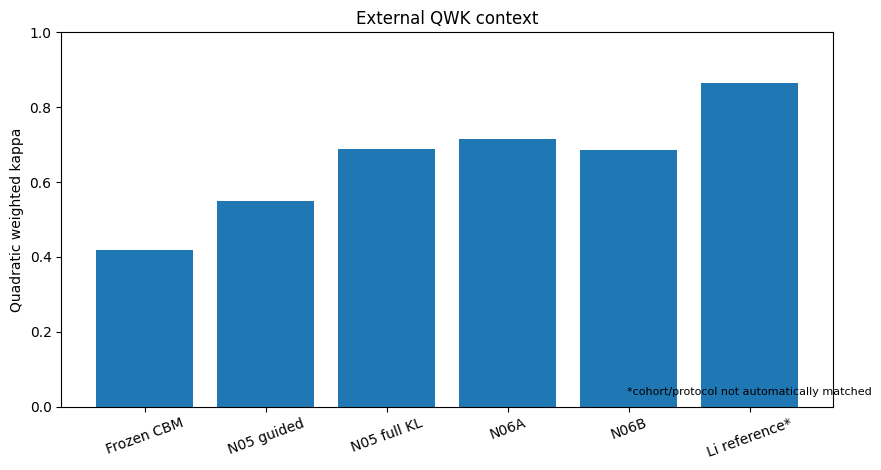

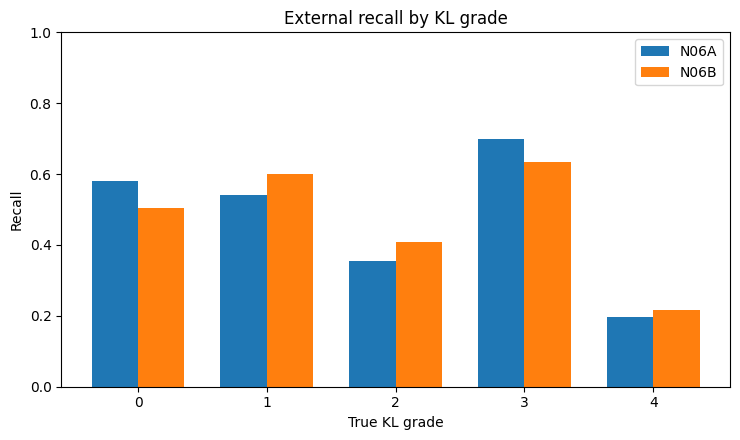

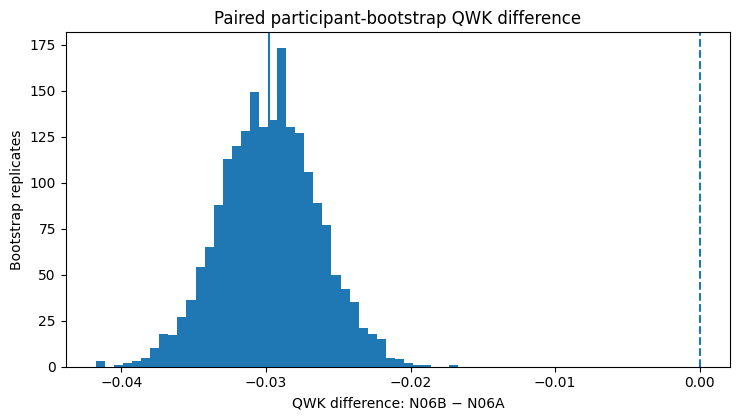

In [ ]:
# 17. Figures

# Figure 1 — external QWK context
fig, ax = plt.subplots(figsize=(9, 4.8))
labels = ['Frozen CBM', 'N05 guided', 'N05 full KL', 'N06A', 'N06B', 'Li reference*']
values = [0.4188, 0.5499, 0.6872, N06A_EXTERNAL_QWK, N06B_EXTERNAL_QWK, CONFIG.li_reference_qwk]
ax.bar(labels, values)
ax.set_ylim(0, 1)
ax.set_ylabel('Quadratic weighted kappa')
ax.set_title('External QWK context')
ax.tick_params(axis='x', rotation=20)
ax.text(5, 0.03, '*cohort/protocol not automatically matched', ha='center', fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'F01_external_qwk_context.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'F01_external_qwk_context.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)

# Figure 2 — N06A vs N06B grade recall when parent grade table is available
if 'n06a_recall' in GRADE_TABLE.columns:
    x = np.arange(len(GRADE_TABLE))
    width = 0.36
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    ax.bar(x - width / 2, GRADE_TABLE['n06a_recall'], width, label='N06A')
    ax.bar(x + width / 2, GRADE_TABLE['n06b_recall'], width, label='N06B')
    ax.set_xticks(x, GRADE_TABLE['kl_grade'].astype(str))
    ax.set_ylim(0, 1)
    ax.set_xlabel('True KL grade')
    ax.set_ylabel('Recall')
    ax.set_title('External recall by KL grade')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / 'F02_grade_recall_n06a_vs_n06b.png', dpi=300, bbox_inches='tight')
    fig.savefig(FIGURE_DIR / 'F02_grade_recall_n06a_vs_n06b.pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)

# Figure 3 — paired bootstrap delta
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.hist(delta_values, bins=40)
ax.axvline(0.0, linestyle='--')
ax.axvline(DELTA_QWK, linestyle='-')
ax.set_xlabel('QWK difference: N06B − N06A')
ax.set_ylabel('Bootstrap replicates')
ax.set_title('Paired participant-bootstrap QWK difference')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'F03_paired_qwk_delta.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'F03_paired_qwk_delta.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)

# 14. N06B certificate and editorial recommendation

`PASS` means the N06B protocol completed correctly. It does **not** require N06B to beat N06A.

For the practical decision about adding both experiments to the thesis, the notebook also prints a non-preregistered editorial recommendation:

- **STRONG_ADD_BOTH**: N06B gains at least 0.015 QWK over N06A, the paired 95% CI is entirely above zero, and OAI test QWK does not fall by more than 0.02;
- **ADD_BOTH_AS_EXPLORATORY**: N06B is numerically better and the paired lower bound is no worse than -0.005;
- **KEEP_N06A_PRIMARY_N06B_NEGATIVE_OR_APPENDIX**: otherwise.

This recommendation is for reporting strategy, not a statistical acceptance test.

In [ ]:
# 18. Final certificate, artifact manifest, and recommendation

required_artifacts = [
    CONFIG_DIR / 'n06b_config.json',
    CONFIG_DIR / 'n06b_external_evaluation_lock.json',
    RESULT_DIR / 'external_participant_bootstrap.csv',
    RESULT_DIR / 'paired_n06b_minus_n06a_bootstrap.csv',
    TABLE_DIR / 'T05_final_seed_validation.csv',
    TABLE_DIR / 'T06_source_blend_selection.csv',
    TABLE_DIR / 'T08_external_performance.csv',
    TABLE_DIR / 'T09_external_bootstrap_intervals.csv',
    TABLE_DIR / 'T10_paired_n06b_vs_n06a.csv',
    TABLE_DIR / 'T11_external_grade_recall.csv',
    PREDICTION_DIR / 'oai_validation_predictions.csv',
    PREDICTION_DIR / 'oai_test_predictions.csv',
    PREDICTION_DIR / 'nhanes_all_predictions.csv',
    FIGURE_DIR / 'F01_external_qwk_context.png',
    FIGURE_DIR / 'F03_paired_qwk_delta.png',
]

if 'n06a_recall' in GRADE_TABLE.columns:
    required_artifacts.append(FIGURE_DIR / 'F02_grade_recall_n06a_vs_n06b.png')

artifact_rows = []
for path in required_artifacts:
    artifact_rows.append({
        'path': str(path),
        'exists': path.exists(),
        'size_bytes': path.stat().st_size if path.exists() else None,
        'sha256': sha256_file(path) if path.exists() else None,
    })
ARTIFACT_MANIFEST = pd.DataFrame(artifact_rows)
atomic_csv(ARTIFACT_MANIFEST, RESULT_DIR / 'n06b_artifact_manifest.csv')

delta_lower = float(PAIRED_SUMMARY.iloc[0]['delta_lower_95'])
delta_upper = float(PAIRED_SUMMARY.iloc[0]['delta_upper_95'])
oai_delta = TEST_METRICS['qwk'] - PARENT_OAI_TEST_QWK

if DELTA_QWK >= 0.015 and delta_lower > 0.0 and oai_delta >= -0.02:
    EDITORIAL_RECOMMENDATION = 'STRONG_ADD_BOTH'
elif DELTA_QWK > 0.0 and delta_lower >= -0.005:
    EDITORIAL_RECOMMENDATION = 'ADD_BOTH_AS_EXPLORATORY'
else:
    EDITORIAL_RECOMMENDATION = 'KEEP_N06A_PRIMARY_N06B_NEGATIVE_OR_APPENDIX'

criteria = {
    'N06B explicitly exploratory/post-hoc': True,
    'audited N06A parent lock reproduced exactly': parent_recomputed_hash == EXPECTED_PARENT_LOCK_SHA,
    'all three parent checkpoint hashes verified': len(PARENT_CHECKPOINTS) == 3,
    'N06B source manifest equals N06A': SOURCE_MANIFEST_HASH == EXPECTED_SOURCE_SHA,
    'N06B patient split equals N06A': SPLIT_HASH == EXPECTED_SPLIT_SHA,
    'OAI patient split is disjoint': not bool(train_ids & val_ids or train_ids & test_ids or val_ids & test_ids),
    'three fixed N06B seeds are present': len(FINAL_RECORDS) == 3 and set(r['seed'] for r in FINAL_RECORDS) == set(CONFIG.training_seeds),
    'blend selected on OAI validation only': SELECTED_BLEND in BLEND_CANDIDATES,
    'external lock exists': LOCK_PATH.exists(),
    'lock states no NHANES training': lock_check.get('nhanes_used_for_training') is False,
    'lock states no NHANES epoch selection': lock_check.get('nhanes_used_for_epoch_selection') is False,
    'lock states no NHANES blend selection': lock_check.get('nhanes_used_for_blend_selection') is False,
    'lock states no NHANES cutpoint fitting': lock_check.get('nhanes_used_for_cutpoint_fitting') is False,
    'paired N06A/N06B cohort cardinality is exact': len(paired) == len(NHANES),
    'all required artifacts exist': bool(ARTIFACT_MANIFEST['exists'].all()),
}
PASSED = all(criteria.values())

STATUS = {
    'stage': STAGE,
    'protocol': PROTOCOL,
    'status': 'PASS' if PASSED else 'FAIL',
    'exploratory_post_hoc': True,
    'parent_stage': PARENT_STAGE,
    'parent_lock_sha256': EXPECTED_PARENT_LOCK_SHA,
    'backbone': BACKBONE_NAME,
    'selected_blend': SELECTED_BLEND,
    'selected_blend_weights': SELECTED_WEIGHTS,
    'oai_validation_metrics': VAL_METRICS,
    'oai_test_metrics': TEST_METRICS,
    'oai_test_argmax_metrics': TEST_ARGMAX_METRICS,
    'nhanes_all_metrics': EXTERNAL_METRICS,
    'nhanes_argmax_metrics': EXTERNAL_ARGMAX_METRICS,
    'n06a_external_qwk': N06A_EXTERNAL_QWK,
    'n06b_minus_n06a_external_qwk': DELTA_QWK,
    'paired_delta_95': [delta_lower, delta_upper],
    'n06b_minus_n06a_oai_test_qwk': oai_delta,
    'li_reference_qwk': CONFIG.li_reference_qwk,
    'editorial_recommendation': EDITORIAL_RECOMMENDATION,
    'external_status_note': FINAL_LOCK['external_status_note'],
    'criteria': criteria,
    'config_hash': CONFIG_HASH,
    'source_manifest_hash': SOURCE_MANIFEST_HASH,
    'split_hash': SPLIT_HASH,
    'external_lock_hash': FINAL_LOCK_HASH,
}
atomic_json(STATUS, RESULT_DIR / 'status.json')

certificate = [
    '=' * 84,
    'N06B ORDINAL REFINEMENT AND PAIRED EXTERNAL BENCHMARK CERTIFICATE',
    '=' * 84,
    f"Status: {STATUS['status']}",
    'Mode: EXPLORATORY / POST-HOC',
    f'Parent: N06A lock {EXPECTED_PARENT_LOCK_SHA}',
    f'Backbone: {BACKBONE_NAME}',
    f'Selected source-only blend: {SELECTED_BLEND} {SELECTED_WEIGHTS}',
    f"OAI validation QWK: {VAL_METRICS['qwk']:.4f}",
    f"OAI test QWK: {TEST_METRICS['qwk']:.4f}",
    f"N06A OAI test QWK: {PARENT_OAI_TEST_QWK:.4f}",
    f"OAI QWK change (N06B-N06A): {oai_delta:+.4f}",
    f"NHANES N06B QWK: {N06B_EXTERNAL_QWK:.4f}",
    f"NHANES N06A QWK: {N06A_EXTERNAL_QWK:.4f}",
    f"NHANES paired QWK change (N06B-N06A): {DELTA_QWK:+.4f}",
    f"Paired 95% CI for QWK change: [{delta_lower:.4f}, {delta_upper:.4f}]",
    f"Li 2026 reference QWK: {CONFIG.li_reference_qwk:.4f} (not protocol-matched)",
    f'Editorial recommendation: {EDITORIAL_RECOMMENDATION}',
    '',
]
for key, value in criteria.items():
    certificate.append(f"{key:<66} {'PASS' if value else 'FAIL'}")

certificate += [
    '',
    f'Config SHA-256: {CONFIG_HASH}',
    f'Source-manifest SHA-256: {SOURCE_MANIFEST_HASH}',
    f'Split SHA-256: {SPLIT_HASH}',
    f'External-lock SHA-256: {FINAL_LOCK_HASH}',
    '',
    FINAL_LOCK['external_status_note'],
    '=' * 84,
]

certificate_text = '\n'.join(certificate)
(RESULT_DIR / 'n06b_certificate.txt').write_text(certificate_text, encoding='utf-8')
print(certificate_text)
display(ARTIFACT_MANIFEST)

if not PASSED:
    raise RuntimeError('N06B certificate failed. Repair only the failed protocol/artifact criteria.')

N06B ORDINAL REFINEMENT AND PAIRED EXTERNAL BENCHMARK CERTIFICATE
Status: PASS
Mode: EXPLORATORY / POST-HOC
Parent: N06A lock ae6d8c5362d06683377cd190c35a1ae875094ca4ffa5f94846b893504d395b88
Backbone: convnext_base.fb_in22k_ft_in1k
Selected source-only blend: ce75_ord25 {'ce': 0.75, 'ordinal': 0.25, 'regression': 0.0}
OAI validation QWK: 0.8382
OAI test QWK: 0.8455
N06A OAI test QWK: 0.8489
OAI QWK change (N06B-N06A): -0.0034
NHANES N06B QWK: 0.6852
NHANES N06A QWK: 0.7150
NHANES paired QWK change (N06B-N06A): -0.0298
Paired 95% CI for QWK change: [-0.0364, -0.0231]
Li 2026 reference QWK: 0.8640 (not protocol-matched)
Editorial recommendation: KEEP_N06A_PRIMARY_N06B_NEGATIVE_OR_APPENDIX

N06B explicitly exploratory/post-hoc                               PASS
audited N06A parent lock reproduced exactly                        PASS
all three parent checkpoint hashes verified                        PASS
N06B source manifest equals N06A                                   PASS
N06B patient sp

,path,exists,size_bytes,sha256
0,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,2115,b36d4441b1b3f79af7756899cc42d320a248f0e64271c7...
1,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,3173,b223eddb289afebab9296107f3a6cf58bddd579bfe44bb...
2,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,122786,e354aee7a529fe1c152740c822c07b2e17a2489f06931f...
3,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,127466,54c80e1bbf4dc4567a6705b213233afee2f831154655df...
4,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,682,0167f21d6bc9290e171391778f7119d1e803269ece2208...
5,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,1333,af228f70edcad6a96f21212416c486df343db1de21535a...
6,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,615,8e7fc13188857074dd0cf064c803a5c1c0ca3b1faaefaf...
7,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,223,74b52ecb8d2591be42dff5609ee14b34bc5126e92a0254...
8,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,195,4b5a9322e8a8971bd159b56db9dc91d4db8ef92fdb0e6a...
9,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,493,562313b777199409deac520de7c62cb80dfd9346ec82ff...


## Interpretation after execution

Use the paired N06A-vs-N06B result first.

### If N06B materially improves N06A

If the N06B external QWK is higher and the paired bootstrap interval supports a positive difference, N06A and N06B form a useful two-stage exploratory story:

- **N06A:** stronger direct source model + expanded OAI data greatly raises the performance ceiling;
- **N06B:** ordinal refinement tests whether respecting disease-order structure recovers additional transfer performance.

### If N06B is similar to N06A

A near-tie is still informative: most of the performance gain came from the stronger direct model/data expansion, not the ordinal refinement.

### If N06B is worse

Keep N06A as the primary performance extension and report N06B only as an exploratory negative result or appendix experiment. Do not tune again on NHANES.

### Reporting constraint

N06B is target-label-free during training and selection, but because N06A's NHANES outputs were already inspected before N06B was designed, do not describe N06B as a fresh untouched external validation.